# OSM bakery name classifier

This notebook will be used to test whether a bakery business names can be distinguished from non-bakery business names using the OSM labels as our source of truth. 

It will involve using a model with input 'x' as the cleaned business name and target 'y' as the business label. A simple pipeline will be after splitting the data into training and testing sets, where character-level TF-IDF converts business names into numerical features and a logistic regression will be trained on these numerical features asssociated with business names. The performance of the model can then be evaluated based on the OSM label names and errors will be examined and thresholds can be considered.

In [15]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, confusion_matrix, classification_report, f1_score, precision_score, recall_score)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.base import clone

#Date of OSM training-data snapshot
DATA_DATE = "2026-07-27"

TRAINING_PATH = (Path("../data/interim")/ f"england_osm_training_names_{DATA_DATE}.csv")

osm_training = pd.read_csv(TRAINING_PATH)

print(f"Dataset shape: {osm_training.shape}")

osm_training.head()

Dataset shape: (82894, 5)


,CleanBusinessName,BakeryLabel,DisplayName,LocationCount,SourceCategories
0,wenzel s,1,Wenzel's,82,shop=bakery
1,poundbakery,1,Poundbakery,54,shop=bakery
2,greenhalgh s,1,Greenhalgh's,37,shop=bakery
3,paul,1,Paul,36,shop=bakery
4,warrens bakery,1,Warrens Bakery,31,shop=bakery


# Prepare and inspect data before ML use

For model training, we only require the cleaned business name and the OSM bakery label. The number of useable data and number of names for bakery and non-bakery businesses are inspected to understand the scale of output numbers in the model training and testing.

In [16]:
model_data = (osm_training
              [["DisplayName","CleanBusinessName","BakeryLabel"]]
              .dropna(subset=["CleanBusinessName","BakeryLabel"]).copy()
            )

model_data["BakeryLabel"] = (model_data["BakeryLabel"].astype(int))

print(f"Usable names: {len(model_data)}\n")

print(model_data["BakeryLabel"]
    .value_counts()
    .rename({0: "Non-bakery",1: "Bakery"})
    )

Usable names: 82894

BakeryLabel
Non-bakery    80831
Bakery         2063
Name: count, dtype: int64


It is important to note at this point that the dataset is heavily leaning towards non-bakery names. It means that the overall accuracy of classification may be an inaccurate factor to solely review performance, so the precision, recall and F1 scores should also be examined.

# Split into training and testing data

The data is divided into the classic 80/20 split with stratficiation used to maintain the bakery name proportion in both sets.

In [17]:
X = model_data["CleanBusinessName"]
y = model_data["BakeryLabel"]

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y,
        ))

print(f"Training names: {len(X_train)}")

print(f"Test names: {len(X_test)}")

Training names: 66315
Test names: 16579


# Configure and train initial classifier model

Using a scikit-learn pipeline to connect the TF-IDF text preprocessing to the logistic regression classifier allows for the TF-IDF vocabulary learned in the training data to be consistent when applied to the test data.

The 'analyzer' parameter used in the TF-IDF vectoriser allows the words in the business names to be examined as character sequences withing the word boundary. Also the n-gram parameter ensures that the character lengths examined are between 3 to 5 which should allow for character sequences that are not too general (<3 character sequences) but also not too sparse (>5 character sequences). It also has a minimum document frequency where the character sequence should show up at least twice to avoid considering word fragmetns that occur due to spelling mistakes or unusual words/symbols appearing and reduces noise.

The logistic regression model is used as a simple binary classifier to parse the TF-IDF features. A balanced class weight is implemented here since we know there are likely a lot more non-bakery names than bakery names in the dataset and that could lead to the model favouring the non-bakery class. Setting the class weight to balanced should allow the model to also show importance to bakery name examples rather than predicting non-bakery names most of the time like the dataset shows. The maximum iterations is set to 1000 just to allow enough iterations to converge if needed.

In [18]:
bakery_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=2,
        ),
    ),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
        ),
    ),
])

bakery_model.fit(X_train, y_train,)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'char_wb'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(3, ...)"
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'


# Evaluating model performance at default threshold

A default probability threshold of 0.5 is used by scikit-learn, the effectiveness of this is evaluated first before considering alternative thresholds.

In [19]:
test_predictions = (bakery_model.predict(X_test))

print(classification_report(
    y_test,
    test_predictions,
    target_names=["Non-bakery","Bakery"],
    digits=3,
    zero_division=0,
    ))

              precision    recall  f1-score   support

  Non-bakery      0.994     0.973     0.983     16166
      Bakery      0.422     0.775     0.547       413

    accuracy                          0.968     16579
   macro avg      0.708     0.874     0.765     16579
weighted avg      0.980     0.968     0.973     16579



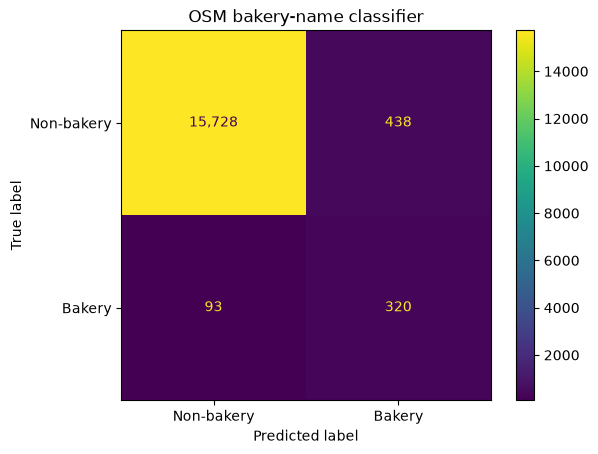

In [20]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    display_labels=["Non-bakery","Bakery"],
    values_format=",d",
    )

plt.title("OSM bakery-name classifier")

plt.show()

The above confusion matrix shows the number of correctly and incorrectly classified bakery names and non-bakery names based on our testing dataset. It helps us summarise and visualise false-positive and false-negative counts to be show 320 correctly identified bakeries, 93 missed bakeries and 438 non-bakeries incorrectly classified as bakeries.

From these results, we find that the default probability threshold of 0.5, correctly identified 320 of the 413 OSM-labelled bakeries, giving bakery recall of 0.775. While this suggests that the model is able to find a large proportion of known bakery names, the precision was only 0.422. The default threshold model found 438 false-positive bakery predictions compared to 320 correctly identified bakeries. More than half of the business names predicted to be bakeries were actually labelled as non-bakeries by the OSM category labels.

It seems that at a 0.5 threshold, there are too many false positives for the predictions to be accepted automatically, meaning that it may be worthwhile comparing alternative probability thresholds and also considering a manual-review stage for business names by creating a confidence level. It's important to not raise the threshold too high as a lower threshold produces more candidate bakery names, with more genuine bakeries but also more false positives. Manual review could then be used to remove these incorrect candidates before creating the final bakery dataset.

## Exploring alternative thresholds and representing through confusion matrix

Alternative thresholds will be examined to compare the trade-off between precision and recall.

Since the aim is to create a comprehensive bakery dataset with as many bakeries identified as possible, both the number of missed bakeries and the amount of manual review required should be considered.

In [21]:
bakery_probabilities = (bakery_model.predict_proba(X_test)[:, 1])

threshold_results = []

for threshold in [0.5, 0.6, 0.7, 0.8, 0.9]:
    threshold_predictions = (bakery_probabilities>= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, threshold_predictions, labels=[0, 1],).ravel()

    threshold_results.append({
        "Threshold": threshold,
        "PredictedBakeries": (threshold_predictions.sum()),
        "TruePositives": tp,
        "FalsePositives": fp,
        "FalseNegatives": fn,
        "TrueNegatives": tn,
        "BakeryPrecision": precision_score(
            y_test,
            threshold_predictions,
            zero_division=0),
        "BakeryRecall": recall_score(
            y_test,
            threshold_predictions,
            zero_division=0),
        "BakeryF1": f1_score(
            y_test,
            threshold_predictions,
            zero_division=0),
    })

threshold_comparison = (pd.DataFrame(threshold_results).round(3))

threshold_comparison

,Threshold,PredictedBakeries,TruePositives,FalsePositives,FalseNegatives,TrueNegatives,BakeryPrecision,BakeryRecall,BakeryF1
0,0.5,758,320,438,93,15728,0.422,0.775,0.547
1,0.6,620,307,313,106,15853,0.495,0.743,0.594
2,0.7,535,301,234,112,15932,0.563,0.729,0.635
3,0.8,452,286,166,127,16000,0.633,0.692,0.661
4,0.9,382,270,112,143,16054,0.707,0.654,0.679


With an increasing probability threshold, the number of predicted bakery names greatly decreases from 758 to 382 and the precision also improves from 0.422 to 0.707. While a greater proportion of predicted bakeries are correctly labelled, the stricter threshold leads to lower recall at 0.654 as opposed to 0.775 at the default threshold. If we wanted to create the best model overall for classification we can also see that the F1 score increases at higher theresholds reaching 0.679. However, the final threshold should not be selected using F1 score in our case as resulting candidate names can also be manually reviewed and the final bakery dataset is intended to include as many bakeries as reasonably possible. This means it may be worth having some more false-positives in our dataset and removing them at a manual review stage rather than increasing the threshold and losing some bakery establishments.

## Illustrative probability bands

These probability bands are exploratory and are not for the purpose of a final classification rule. The main purpose is to show how a manual-review process may be organised and see if separating stronger to weaker bakery candidates may allow for only certain bands to be manually reviewed.

In [22]:
test_results = (model_data.loc[X_test.index, ["DisplayName", "CleanBusinessName", "BakeryLabel"]].copy())

test_results["BakeryProbability"] = (bakery_model.predict_proba(X_test)[:, 1])

def assign_probability_band(probability):
    if probability >= 0.90:
        return "Strong bakery candidate"
    if probability >= 0.70:
        return "Possible bakery candidate"
    if probability >= 0.50:
        return "Weak bakery candidate"
    return "Highly likely non-bakery"

test_results["ProbabilityBand"] = (test_results["BakeryProbability"].apply(assign_probability_band))

test_results["ProbabilityBand"].value_counts()

band_summary = (test_results.groupby("ProbabilityBand", observed=False)
                .agg(TotalNames=("BakeryLabel", "size"),
                     ActualBakeries=("BakeryLabel", "sum"))
                .reset_index())

band_summary["ActualNonBakeries"] = (band_summary["TotalNames"] - band_summary["ActualBakeries"])

band_summary["ObservedBakeryRate(%)"] = (band_summary["ActualBakeries"] / band_summary["TotalNames"]*100)

band_summary.round(3)

,ProbabilityBand,TotalNames,ActualBakeries,ActualNonBakeries,ObservedBakeryRate(%)
0,Highly likely non-bakery,15821,93,15728,0.588
1,Possible bakery candidate,153,31,122,20.261
2,Strong bakery candidate,382,270,112,70.681
3,Weak bakery candidate,223,19,204,8.520


The probability bands are a good example for showing the bands that might be a priority in the manual review.

No final threshold or banding is selected in this notebook, and a practical review must first be assessed on the FHRS business-name dataset.

In [23]:
MODEL_FOLDER = Path("../models")
MODEL_FOLDER.mkdir(parents=True, exist_ok=True)

MODEL_PATH = (MODEL_FOLDER / "osm_bakery_name_classifier.joblib")

# Creating unfitted copy of model
final_bakery_model = clone(bakery_model)

final_bakery_model.fit(X,y)

joblib.dump(final_bakery_model, MODEL_PATH)

print(f"Model saved to: {MODEL_PATH}")

Model saved to: ..\models\osm_bakery_name_classifier.joblib
